# Clustering de Altiplanos (v2) — Tipología morfométrica de los 491 polígonos

## Introducción

**Qué se busca:** se cuenta con 491 polígonos delimitados manualmente, cada uno
identificado previamente como "altiplano" a partir de criterios de relieve relativo,
pendiente y altitud. Estos polígonos **no son contiguos entre sí** (no comparten borde ni
se tocan), por lo que no representan un mosaico continuo del territorio sino "parches"
aislados de superficie de aplanamiento.

El objetivo de este notebook es **clasificar (tipificar)** esos 491 altiplanos en grupos
morfométricos homogéneos, es decir, responder: ¿existen "tipos" de altiplano (p. ej. altos
y escarpados vs. bajos y suaves) y cuáles polígonos pertenecen a cada tipo? Este es el
cluster **de altiplanos** (a diferencia del cluster **de píxeles** de
`Clustering_Regiones_v2.ipynb`, que busca zonas con distribución/características distintas
para usarse como agrupación del modelo jerárquico) — aquí buscamos comprender cómo se
agrupan estas superficies según sus características propias, no construir una zonificación
del territorio.

**Método del libro utilizado:** notebook `08_ClusterEspacial` del libro *Análisis
Geoespacial* (Aristizábal). Como los polígonos NO son contiguos, la matriz de pesos
espaciales tipo Queen/Rook no es aplicable (cada polígono aislado quedaría como "isla" sin
vecinos). Por esta razón este notebook usa la parte **no espacial** del mismo capítulo:
clustering de atributos con K-means y clustering jerárquico (Ward), tratando cada altiplano
como una observación multivariada descrita por su perfil de altitud, relieve y pendiente.
La variante con restricción espacial (KNN/DistanceBand sobre centroides) se explora aparte
en `02_clustering_espacial_altiplanos_v2.ipynb`.

**Ventajas / desventajas de este enfoque (clustering de atributos vs. regionalización
espacial):**
- (+) Es el método correcto cuando las unidades no tienen una relación de vecindad
  geográfica real que deba respetarse.
- (+) Permite encontrar similitudes morfométricas entre altiplanos muy alejados entre sí.
- (-) Ignora por completo la ubicación geográfica.

**Cambios respecto a la versión anterior de este notebook (`01_clustering_altiplanos.py` /
la primera versión de `01_clustering_altiplanos_v2.ipynb`):** convertido a `.ipynb` real con
celdas markdown/código alternadas; se agregó la sección de exploración de datos
(estadísticas, histogramas, área, N) exigida por la skill del proyecto; el número de
clusters (`K_ELEGIDO`) ya no se fija a mano en 4, sino que se elige con criterio explícito
(mejor Silhouette exigiendo `n_clusters >= 4`); **se retiró el índice de Calinski-Harabasz**
(no forma parte del método del libro — se había agregado en una etapa previa de este mismo
proyecto, no en `08_ClusterEspacial`, así que se deja solo el método del codo + Silhouette,
que sí son los criterios que usa el libro); y **se retiró por completo la sección de
TimeSeriesKMeans/DTW** (ver justificación abajo).


## [0] Configuración: rutas, semilla y carpeta de resultados de este notebook


In [1]:
# --- Librerías estándar de Python ---
import struct   # struct: leer bytes crudos del encabezado del .dbf (ver función de abajo)
import os       # os: manejo de rutas y creación de carpetas del sistema

# --- Librerías científicas / de datos ---
import numpy as np              # numpy: arreglos y operaciones numéricas vectorizadas
import pandas as pd             # pandas: tablas (DataFrame) para las variables morfométricas
import geopandas as gpd         # geopandas: pandas + geometría (lee shapefiles, maneja el CRS)
import matplotlib.pyplot as plt # matplotlib: motor de todas las figuras
import seaborn as sns           # seaborn: gráficos estadísticos de alto nivel (histogramas, heatmaps)

# --- Algoritmos de scikit-learn y scipy ---
from sklearn.preprocessing import StandardScaler          # estandariza cada variable a media 0 y desv. 1
from sklearn.cluster import KMeans, AgglomerativeClustering  # los dos algoritmos de clustering usados
from sklearn.metrics import silhouette_score              # métrica de calidad del clustering (Silhouette)
from scipy.cluster.hierarchy import dendrogram, linkage   # árbol jerárquico (Ward) y su gráfico

# Configuracion general de rutas del proyecto
# Prefijo r"..." = raw string: los backslashes de Windows NO se interpretan como escapes.
RUTA_SHP = r"C:\Users\MSI\Desktop\Universidad\Analisis_Geoespacial\Capas\Estadisticas_Cluster.shp"  # geometría + atributos
RUTA_DBF = r"C:\Users\MSI\Desktop\Universidad\Analisis_Geoespacial\Capas\Estadisticas_Cluster.dbf"  # tabla del shapefile (nombres de columna)
CARPETA_RESULTADOS = r"C:\Users\MSI\Desktop\Universidad\Analisis_Geoespacial\Resultados"
CARPETA_FIGURAS = os.path.join(CARPETA_RESULTADOS, "01_clustering_altiplanos_v2")  # subcarpeta propia de este notebook
os.makedirs(CARPETA_FIGURAS, exist_ok=True)  # crea la carpeta; exist_ok=True evita error si ya existe

SEMILLA = 42  # fija la aleatoriedad para que los resultados sean reproducibles
N_CLUSTERS_MINIMO = 4  # se descartan k=2 y k=3 al elegir el mejor Silhouette (ver seccion [6])

print(f"Carpeta de figuras de este notebook: {CARPETA_FIGURAS}")

Carpeta de figuras de este notebook: C:\Users\MSI\Desktop\Universidad\Analisis_Geoespacial\Resultados\01_clustering_altiplanos_v2


## [1] Utilidad: corrección de codificación del `.dbf`

El archivo `.dbf` de este shapefile tiene un defecto conocido de ArcGIS/GDAL: el `.cpg`
declara UTF-8, y los VALORES de texto (p. ej. "Geología") se leen bien con ese encoding,
pero pyogrio/GDAL no aplica el encoding declarado a los NOMBRES DE COLUMNA, por lo que
columnas como "Geología" o "Área" llegan corruptas (con caracteres de reemplazo).
Verificado leyendo los bytes crudos del encabezado del `.dbf`: son UTF-8 válido, así que
basta con leer el nombre de cada campo directamente del encabezado binario del archivo y
renombrar las columnas del GeoDataFrame.


In [2]:
def nombres_reales_columnas_dbf(ruta_dbf: str, encoding: str = "utf-8") -> list[str]:
    '''Lee los nombres de campo directamente del encabezado binario del .dbf.

    Esto evita el error de decodificacion que pyogrio/GDAL introduce en los
    nombres de columna (no en los valores) de archivos .dbf con acentos.
    '''
    # Abre el .dbf en modo binario ("rb") para leer bytes crudos, no texto.
    with open(ruta_dbf, "rb") as f:
        encabezado = f.read(32)                              # los primeros 32 bytes = encabezado del archivo
        # struct.unpack("<H", ...): interpreta 2 bytes (posiciones 8-9) como entero sin signo
        # little-endian ("<H") = tamaño total del encabezado en bytes.
        tam_encabezado = struct.unpack("<H", encabezado[8:10])[0]
        f.seek(0)                                            # vuelve al inicio del archivo
        encabezado_completo = f.read(tam_encabezado)         # lee TODO el encabezado (contiene los nombres)

    nombres = []
    offset = 32                                              # los descriptores de campo empiezan tras los 32 bytes iniciales
    while True:
        descriptor = encabezado_completo[offset:offset + 32] # cada campo ocupa 32 bytes
        # 0x0D marca el fin de la lista de campos
        if descriptor[0:1] == b"\x0d" or len(descriptor) < 32:
            break
        crudo = descriptor[0:11].split(b"\x00")[0]          # nombre = primeros 11 bytes hasta el primer byte nulo
        nombres.append(crudo.decode(encoding))               # decodifica esos bytes como UTF-8 (respeta acentos)
        offset += 32                                         # avanza al siguiente descriptor de campo
    return nombres                                           # devuelve la lista de nombres correctos

## [2] Carga de datos


In [3]:
gdf = gpd.read_file(RUTA_SHP)  # lee el shapefile -> GeoDataFrame (una fila por polígono de altiplano)

# El .dbf trae los nombres de columna corruptos (acentos); se reemplazan por los correctos
# leídos del encabezado binario. Se añade "geometry" (la columna geométrica que agrega geopandas).
nombres_corregidos = nombres_reales_columnas_dbf(RUTA_DBF) + ["geometry"]
assert len(nombres_corregidos) == len(gdf.columns), (   # assert: aborta si el conteo no cuadra (chequeo de seguridad)
    "El numero de nombres leidos del .dbf no coincide con el numero de "
    "columnas del GeoDataFrame; revisar manualmente antes de continuar."
)
gdf.columns = nombres_corregidos  # reasigna los nombres de columna corregidos

print(f"Poligonos cargados: {len(gdf)}")          # len(gdf) = número de filas = número de altiplanos
print(f"CRS: {gdf.crs}")                          # CRS = sistema de coordenadas (EPSG:32618, en metros)
print(f"Columnas: {list(gdf.columns)}")

Poligonos cargados: 491
CRS: EPSG:32618
Columnas: ['Altitud_X', 'Altitud_St', 'Relieve_X', 'Relieve_St', 'Pend_X', 'Pend_St', 'Num', 'Alt_90', 'Alt_50', 'Alt_10', 'Geo_Value', 'Geología', 'Área', 'Rel_90', 'Rel_50', 'Rel_10', 'Slp_90', 'Slp_50', 'Slp_10', 'Latitud', 'Lat_Max', 'Lat_Min', 'Longitud', 'Lon_Max', 'Lon_Min', 'geometry']


## [3] Exploración de datos

**Qué se busca:** antes de ajustar cualquier modelo de clustering, describir la calidad y
forma de los datos: valores nulos, distribución de la variable categórica, estadísticas
descriptivas de las variables morfométricas, sus histogramas, y el área total/promedio de
los 491 polígonos. Esto corresponde al primer paso de cualquier análisis de datos de área
del libro (`00_Data` / `01_DatosEspaciales`): nunca modelar sin antes conocer los datos.


In [4]:
print("Valores nulos por columna:")
nulos = gdf.isna().sum()   # isna() -> matriz True/False de nulos; .sum() cuenta por columna
# Si hay algún nulo muestra el conteo por columna; si no, imprime "(ninguno)".
print(nulos[nulos > 0] if nulos.sum() > 0 else "  (ninguno)")

print("\nDistribucion de la variable categorica Geologia:")
print(gdf["Geología"].value_counts())  # value_counts() = frecuencia de cada categoría litológica

Valores nulos por columna:
  (ninguno)

Distribucion de la variable categorica Geologia:
Geología
I. Plutónica      214
S. Medio          135
M. Medio grado     71
I. Volcánica       55
M. Alto grado      12
S. Gruesos          3
S. Fino             1
Name: count, dtype: int64


In [5]:
# Lista de variables morfométricas a resumir (medias, desviaciones y percentiles de altitud).
variables_resumen = ["Altitud_X", "Altitud_St", "Alt_90", "Alt_50", "Alt_10", "Relieve_X", "Relieve_St", "Pend_X", "Pend_St"]
# .describe() = estadísticas (count, mean, std, min, cuartiles, max); .T las transpone (una fila por variable).
# Al ser la última expresión de la celda, Jupyter la muestra como tabla.
gdf[variables_resumen].describe().T

,count,mean,std,min,25%,50%,75%,max
Altitud_X,491.0,1258.583772,725.172427,412.92700,671.572500,1017.70000,1625.000000,3608.26000
Altitud_St,491.0,35.180404,17.408620,10.82730,24.818600,30.68970,40.790650,145.42300
Alt_90,491.0,1305.002037,731.833993,452.00000,711.500000,1071.00000,1666.500000,3652.00000
Alt_50,491.0,1257.702648,725.093962,414.00000,672.000000,1012.00000,1623.500000,3613.00000
Alt_10,491.0,1213.081466,718.941905,327.00000,633.500000,977.00000,1574.000000,3556.00000
Relieve_X,491.0,44.420052,6.890411,26.68940,39.146500,44.72900,48.954350,76.22060
Relieve_St,491.0,12.384614,3.067975,6.09171,10.382500,11.84300,13.607500,29.01610
Pend_X,491.0,11.977463,1.956846,6.80707,10.528950,12.12650,13.308650,18.21580
Pend_St,491.0,6.058210,0.841685,3.74317,5.488865,6.03498,6.617085,8.66125


**Histogramas de las variables morfométricas clave:** para ver la forma de la distribución
(simetría, colas, posibles outliers) de altitud, relieve y pendiente antes de estandarizar
y agrupar.


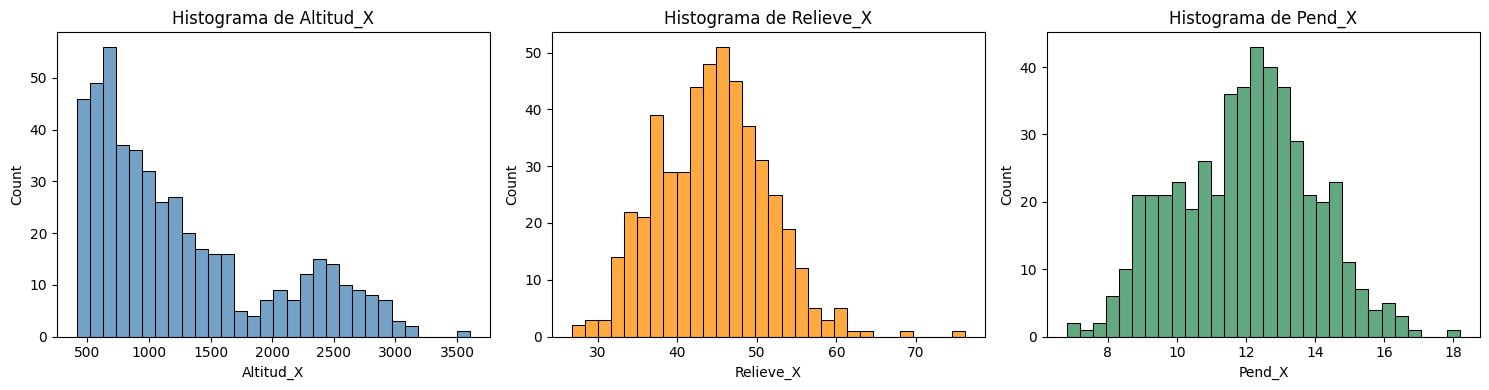

In [6]:
# subplots(1, 3): una fila de 3 ejes; figsize en pulgadas (ancho, alto).
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
# zip empareja cada eje con su variable y su color; se dibuja un histograma por variable.
for ax, var, color in zip(axes, ["Altitud_X", "Relieve_X", "Pend_X"], ["steelblue", "darkorange", "seagreen"]):
    sns.histplot(gdf[var], bins=30, color=color, ax=ax)  # histograma con 30 barras en el eje ax
    ax.set_title(f"Histograma de {var}")
    ax.set_xlabel(var)
plt.tight_layout()  # ajusta márgenes para que no se solapen los títulos/ejes
# savefig: guarda la figura como PNG a 150 dpi (puntos por pulgada = resolución) en la carpeta del notebook.
plt.savefig(os.path.join(CARPETA_FIGURAS, "00_histogramas_variables.png"), dpi=150)
plt.show()  # renderiza la figura en la salida de la celda

**Área de los polígonos:** el área ya viene calculada en la columna `Área` (proveniente de
ArcGIS). Se contrasta contra `geometry.area` (calculada directamente de la geometría en
EPSG:32618, una proyección plana en metros) como verificación cruzada.


In [7]:
# Tres formas de medir el área: la columna 'Área' del shapefile, la geometría real, y el promedio.
# / 1e6 convierte de m² a km² (1 km² = 1.000.000 m²).
area_columna_km2 = gdf["Área"].sum() / 1e6
area_geometria_km2 = gdf.geometry.area.sum() / 1e6   # .geometry.area recalcula el área desde los polígonos (CRS en metros)
area_promedio_km2 = gdf["Área"].mean() / 1e6

print(f"N = {len(gdf)} poligonos (los 491 delimitados a mano; ninguno se excluye, no hay NoData en datos vectoriales)")
# {valor:,.2f} = 2 decimales con separador de miles.
print(f"Area total (columna 'Area'): {area_columna_km2:,.2f} km2")
print(f"Area total (geometry.area, verificacion cruzada): {area_geometria_km2:,.2f} km2")
print(f"Area promedio por poligono: {area_promedio_km2:,.3f} km2 ({gdf['Área'].mean():,.0f} m2)")
print(f"Area minima: {gdf['Área'].min():,.0f} m2   Area maxima: {gdf['Área'].max():,.0f} m2")

N = 491 poligonos (los 491 delimitados a mano; ninguno se excluye, no hay NoData en datos vectoriales)
Area total (columna 'Area'): 0.01 km2
Area total (geometry.area, verificacion cruzada): 9,366.53 km2
Area promedio por poligono: 0.000 km2 (19 m2)
Area minima: 0 m2   Area maxima: 1,316 m2


## [4] Selección de variables y estandarización

Se usan las 6 variables de media y desviación estándar de altitud, relieve y pendiente, MÁS
los tres percentiles de altitud (`Alt_90`, `Alt_50`, `Alt_10`) que ya trae la tabla de
datos. Estos percentiles no son redundantes con `Altitud_X`/`Altitud_St`: la media y la
desviación estándar resumen la distribución de altitud dentro del polígono asumiendo
(implícitamente) una forma aproximadamente simétrica, mientras que los percentiles permiten
distinguir altiplanos con una distribución de altitud sesgada de otro con una distribución
simétrica, aunque ambos compartan la misma media y desviación estándar. El **Área** no se
incluye porque es una medida de TAMAÑO del polígono (depende de cómo se digitalizó a mano),
no de su morfometría interna, y **Geología** se deja fuera por ser categórica (K-means solo
trabaja con distancia euclidiana sobre variables continuas).

**Método del libro utilizado:** igual que en `08_ClusterEspacial`, se estandarizan las
variables con `StandardScaler` ANTES de aplicar el algoritmo — indispensable porque
Altitud está en metros (cientos-miles), Relieve en metros (decenas) y Pendiente en grados
(unidades): sin estandarizar, la Altitud dominaría por completo la distancia euclidiana.

**Ventajas / desventajas de estandarizar con media=0 y desv.=1:**
- (+) Pone a las tres variables en pie de igualdad para el cálculo de distancias.
- (-) Es sensible a valores atípicos extremos; con datos muy sesgados a veces conviene
  `RobustScaler`. Aquí se usa `StandardScaler` por ser el estándar del libro y porque los
  datos no muestran outliers extremos (ver histogramas de la sección [3]).


In [8]:
# Las 9 variables que entran al clustering: media y desv. estándar de altitud/relieve/pendiente
# + percentiles de altitud (Alt_90/50/10). Se excluye Área (tamaño) y Geología (categórica).
variables_cluster = [
    "Altitud_X", "Altitud_St", "Alt_90", "Alt_50", "Alt_10",
    "Relieve_X", "Relieve_St", "Pend_X", "Pend_St",
]

escalador = StandardScaler()  # objeto que estandariza: a cada variable le resta su media y divide por su desv.
# fit_transform: (1) aprende media/desv de cada columna y (2) devuelve la matriz ya estandarizada (numpy array).
X_estandarizado = escalador.fit_transform(gdf[variables_cluster])
# Se envuelve en DataFrame solo para conservar nombres de columna e índice (útil para inspección).
X_estandarizado_df = pd.DataFrame(X_estandarizado, columns=variables_cluster, index=gdf.index)

# .shape = (filas, columnas) del array: 491 polígonos x 9 variables.
print(f"Matriz estandarizada: {X_estandarizado.shape[0]} poligonos x {X_estandarizado.shape[1]} variables")

Matriz estandarizada: 491 poligonos x 9 variables


## [5] Correlación entre variables (chequeo previo)

Se verifica que no haya variables casi perfectamente redundantes (p. ej. correlación >
0.95) antes de agruparlas, ya que dos variables muy correlacionadas pesarían el doble en la
distancia euclidiana sin aportar información nueva.


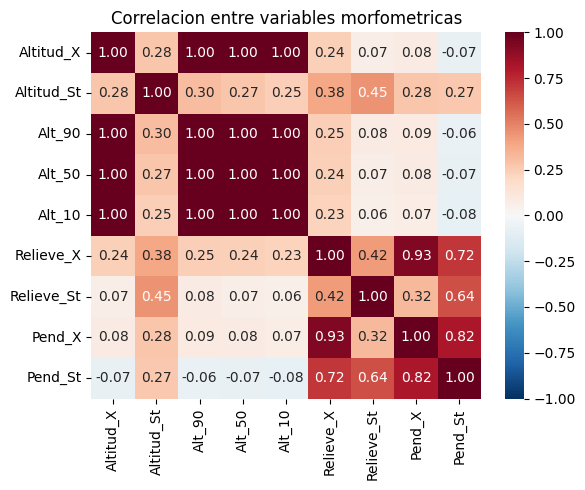

In [9]:
correlacion = gdf[variables_cluster].corr()  # matriz de correlación de Pearson entre las 9 variables

plt.figure(figsize=(6, 5))
# heatmap: color = correlación; annot=True escribe el número; fmt=".2f" con 2 decimales;
# cmap RdBu_r y vmin/vmax=-1/1 centran el 0 en blanco (rojo=+, azul=-).
sns.heatmap(correlacion, annot=True, fmt=".2f", cmap="RdBu_r", vmin=-1, vmax=1)
plt.title("Correlacion entre variables morfometricas")
plt.tight_layout()
plt.savefig(os.path.join(CARPETA_FIGURAS, "01_correlacion_variables.png"), dpi=150)
plt.show()

## [6] Número óptimo de clusters: codo y Silhouette

**Qué se busca:** K-means exige fijar de antemano el número de grupos (k). Para elegirlo de
forma informada se prueban k=2 a 50 y se comparan los DOS criterios que usa el libro en
`08_ClusterEspacial`: inercia (método del codo) y el coeficiente de Silhouette (SS).

**Ventajas / desventajas de cada criterio:**
- **Método del codo (inercia):** (+) fácil de calcular e interpretar visualmente;
  (-) subjetivo, el "codo" no siempre es un quiebre claro.
- **Silhouette:** (+) número objetivo entre -1 y 1, comparable entre valores de k;
  (-) costoso (O(n²)) y favorece clusters convexos de tamaño similar.

Con solo 491 polígonos, valores de k cercanos a 50 implican grupos de menos de 10
altiplanos en promedio; más allá de cierto punto los "clusters" dejan de representar tipos
geomorfológicos genuinos y empiezan a aislar observaciones individuales.


In [10]:
rango_k = range(2, 51)          # se prueban k = 2, 3, ..., 50 clusters
inercias, siluetas = [], []     # listas para acumular las dos métricas por cada k

for k in rango_k:
    # KMeans: n_clusters=k grupos; random_state=SEMILLA reproducible; n_init=10 = 10 arranques
    # distintos y se queda con el mejor (evita mínimos locales por mala inicialización).
    modelo_k = KMeans(n_clusters=k, random_state=SEMILLA, n_init=10)
    etiquetas_k = modelo_k.fit_predict(X_estandarizado)     # ajusta y devuelve la etiqueta de cluster de cada polígono
    inercias.append(modelo_k.inertia_)                     # inercia = suma de distancias² al centroide (método del codo)
    siluetas.append(silhouette_score(X_estandarizado, etiquetas_k))  # Silhouette medio (-1 a 1; más alto = mejor)

rango_k = list(rango_k)  # convierte el range a lista para poder graficarlo/indexarlo después
print("Barrido k=2..50 completado.")

C:\Users\MSI\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
C:\Users\MSI\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
C:\Users\MSI\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
C:\Users\MSI\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with M

C:\Users\MSI\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
C:\Users\MSI\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
C:\Users\MSI\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
C:\Users\MSI\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with M

C:\Users\MSI\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
C:\Users\MSI\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
C:\Users\MSI\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
C:\Users\MSI\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with M

C:\Users\MSI\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
C:\Users\MSI\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
C:\Users\MSI\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
C:\Users\MSI\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with M

C:\Users\MSI\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
C:\Users\MSI\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
C:\Users\MSI\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
C:\Users\MSI\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with M

...

C:\Users\MSI\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
C:\Users\MSI\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
C:\Users\MSI\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
C:\Users\MSI\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with M

C:\Users\MSI\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
C:\Users\MSI\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
C:\Users\MSI\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
C:\Users\MSI\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with M

C:\Users\MSI\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
C:\Users\MSI\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
C:\Users\MSI\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
C:\Users\MSI\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with M

Barrido k=2..50 completado.


C:\Users\MSI\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


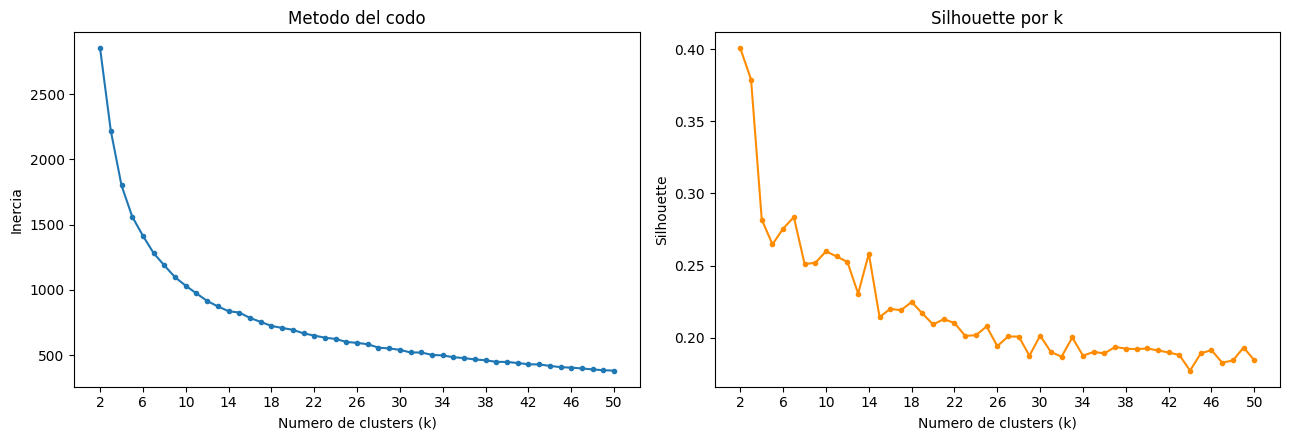

Mejor k SIN restriccion segun Silhouette: 2 (SS=0.401)


In [11]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.5))  # dos gráficos lado a lado

# Panel izquierdo: método del codo (inercia vs k). marker="o" pone puntos en cada k.
ax1.plot(rango_k, inercias, marker="o", markersize=3)
ax1.set_xlabel("Numero de clusters (k)"); ax1.set_ylabel("Inercia"); ax1.set_title("Metodo del codo")
ax1.set_xticks(list(range(2, 51, 4)))  # marcas del eje X cada 4 unidades

# Panel derecho: Silhouette vs k.
ax2.plot(rango_k, siluetas, marker="o", markersize=3, color="darkorange")
ax2.set_xlabel("Numero de clusters (k)"); ax2.set_ylabel("Silhouette"); ax2.set_title("Silhouette por k")
ax2.set_xticks(list(range(2, 51, 4)))

plt.tight_layout()
plt.savefig(os.path.join(CARPETA_FIGURAS, "02_seleccion_k.png"), dpi=150)
plt.show()

# np.argmax(siluetas) = índice del Silhouette más alto; rango_k[...] = el k correspondiente.
mejor_k_silhouette_sin_restriccion = rango_k[int(np.argmax(siluetas))]
print(f"Mejor k SIN restriccion segun Silhouette: {mejor_k_silhouette_sin_restriccion} (SS={max(siluetas):.3f})")

**Decisión de K:** el máximo global de Silhouette cae en k=2, pero una partición de solo 2
grupos no tiene suficiente resolución geomorfológica para caracterizar la variedad de
altiplanos de este estudio. En vez de fijar `K_ELEGIDO=4` a mano, aquí se aplica un
criterio explícito y reproducible: se restringe la búsqueda del mejor Silhouette a
`n_clusters >= N_CLUSTERS_MINIMO` (4), descartando k=2 y k=3 ANTES de tomar el máximo, no
después.


In [12]:
# Filtra los pares (k, Silhouette) dejando solo k >= 4 (descarta k=2 y k=3 por poco útiles).
candidatos_validos = [(k, ss) for k, ss in zip(rango_k, siluetas) if k >= N_CLUSTERS_MINIMO]
# max(..., key=lambda par: par[1]): toma el par con mayor Silhouette (elemento [1] de cada tupla).
K_ELEGIDO, mejor_ss_restringido = max(candidatos_validos, key=lambda par: par[1])

print(f"Mejor k con n_clusters >= {N_CLUSTERS_MINIMO} segun Silhouette: k={K_ELEGIDO} (SS={mejor_ss_restringido:.3f})")
print(f"(referencia, sin restriccion: k={mejor_k_silhouette_sin_restriccion}, SS={max(siluetas):.3f})")
print(f"\nK_ELEGIDO = {K_ELEGIDO}")

Mejor k con n_clusters >= 4 segun Silhouette: k=7 (SS=0.284)
(referencia, sin restriccion: k=2, SS=0.401)

K_ELEGIDO = 7


## [7] Clustering K-means (modelo final)

Se asigna a cada uno de los 491 altiplanos una etiqueta de grupo (0, 1, 2, ...) según su
perfil morfométrico estandarizado, con `K_ELEGIDO` obtenido en el paso anterior.

**Ventajas / desventajas de K-means en general:**
- (+) Simple, rápido y escalable incluso con miles de observaciones.
- (+) Fácil de interpretar: cada cluster queda representado por su centroide.
- (-) Asume que los grupos son razonablemente esféricos y de tamaño similar.
- (-) El resultado depende de la inicialización aleatoria (mitigado con `n_init=10`).
- (-) No maneja directamente variables categóricas (por eso Geología queda fuera del
  algoritmo, aunque se usa para interpretar los grupos ya formados en la sección [10]).


In [13]:
# Ajuste FINAL de K-means con el k elegido; guarda la etiqueta de cluster como columna nueva del GeoDataFrame.
modelo_kmeans = KMeans(n_clusters=K_ELEGIDO, random_state=SEMILLA, n_init=10)
gdf["cluster_kmeans"] = modelo_kmeans.fit_predict(X_estandarizado)  # 0..K-1 por polígono

print("Numero de altiplanos por cluster (K-means):")
# value_counts() cuenta cuántos polígonos hay por cluster; sort_index() los ordena por número de cluster.
print(gdf["cluster_kmeans"].value_counts().sort_index())

Numero de altiplanos por cluster (K-means):
cluster_kmeans
0     95
1      9
2     56
3     51
4    118
5     44
6    118
Name: count, dtype: int64


C:\Users\MSI\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


## [8] Clustering jerárquico (Ward) como contraste

Se compara el resultado de K-means con un método alternativo que no depende de una
inicialización aleatoria ni de fijar k desde el principio, para verificar que la tipología
encontrada es robusta y no un artefacto de un solo algoritmo.

**Ventajas / desventajas del clustering jerárquico (Ward):**
- (+) No requiere decidir k de antemano: el dendrograma se puede "cortar" a distintas
  alturas sin recalcular nada.
- (+) Determinista (no depende de una semilla aleatoria como K-means).
- (-) Computacionalmente más costoso (O(n²)), poco práctico para decenas de miles de
  observaciones (con 491 polígonos no es un problema).
- (-) Una vez fusionadas dos observaciones, la decisión es irreversible.


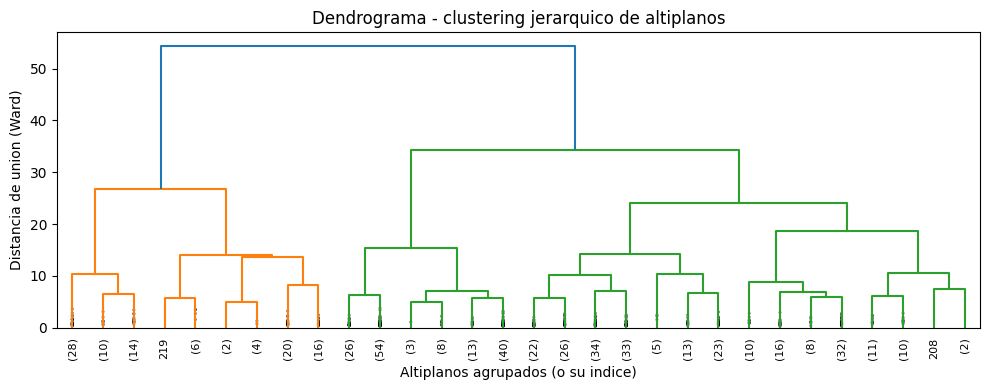

In [14]:
# linkage(method="ward"): construye el árbol jerárquico fusionando los grupos que menos aumentan
# la varianza intra-cluster (criterio de Ward); metric="euclidean" = distancia euclidiana.
matriz_enlace = linkage(X_estandarizado, method="ward", metric="euclidean")

plt.figure(figsize=(10, 4))
# dendrogram dibuja el árbol; truncate_mode="lastp", p=30 muestra solo las últimas 30 fusiones
# (el árbol completo tiene 491 hojas, ilegible). show_leaf_counts pone el nº de elementos por rama.
dendrogram(matriz_enlace, truncate_mode="lastp", p=30, leaf_rotation=90.0, leaf_font_size=8,
           show_leaf_counts=True, show_contracted=True)
plt.xlabel("Altiplanos agrupados (o su indice)")
plt.ylabel("Distancia de union (Ward)")
plt.title("Dendrograma - clustering jerarquico de altiplanos")
plt.tight_layout()
plt.savefig(os.path.join(CARPETA_FIGURAS, "03_dendrograma.png"), dpi=150)
plt.show()

In [15]:
# Segundo algoritmo: clustering jerárquico aglomerativo cortado en K_ELEGIDO grupos (linkage Ward).
modelo_ward = AgglomerativeClustering(n_clusters=K_ELEGIDO, linkage="ward")
gdf["cluster_ward"] = modelo_ward.fit_predict(X_estandarizado)  # etiqueta Ward por polígono

# crosstab: tabla de contingencia = cuántos polígonos caen en cada combinación (cluster K-means, cluster Ward).
# Sirve para ver si ambos algoritmos coinciden en la tipología.
tabla_comparacion = pd.crosstab(gdf["cluster_kmeans"], gdf["cluster_ward"])
print("Tabla de contingencia K-means (filas) vs. Ward (columnas):")
print(tabla_comparacion)

Tabla de contingencia K-means (filas) vs. Ward (columnas):
cluster_ward     0   1   2   3   4   5   6
cluster_kmeans                            
0               93   0   0   1   0   0   1
1                0   7   2   0   0   0   0
2               23   0  22   0   0  11   0
3                2  42   0   7   0   0   0
4                7   0   0   0  64   0  47
5                0   0   0  44   0   0   0
6               31   0   0   0   0  55  32


## [9] Mapa de los clusters

Aunque el clustering no usa la ubicación geográfica como variable, mapear el resultado
permite ver si los tipos morfométricos tienen además algún patrón espacial, pregunta que se
retoma con autocorrelación espacial en `04_autocorrelacion_espacial_v2.ipynb`.


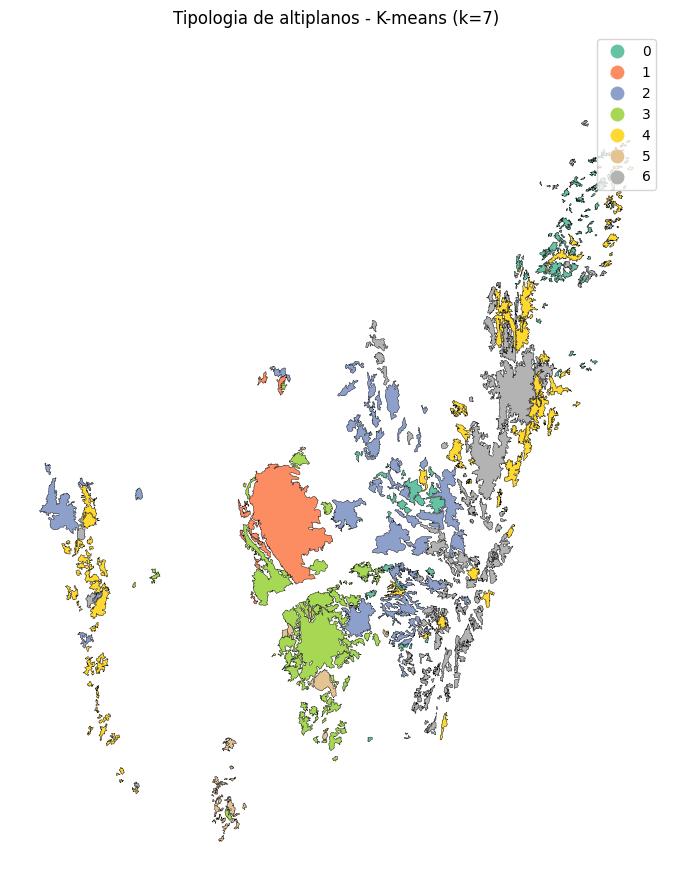

In [16]:
fig, ax = plt.subplots(1, figsize=(9, 9))
# gdf.plot(column=...): mapa temático coloreado por la columna de cluster.
# categorical=True trata los valores como categorías (no un gradiente); cmap="Set2" = paleta cualitativa;
# edgecolor/linewidth dibujan el borde de cada polígono; legend=True agrega la leyenda.
gdf.plot(column="cluster_kmeans", categorical=True, legend=True, cmap="Set2",
         edgecolor="black", linewidth=0.3, ax=ax)
ax.set_title(f"Tipologia de altiplanos - K-means (k={K_ELEGIDO})")
ax.set_axis_off()  # oculta los ejes de coordenadas (no aportan en un mapa temático)
plt.tight_layout()
plt.savefig(os.path.join(CARPETA_FIGURAS, "04_mapa_clusters.png"), dpi=150)
plt.show()

### [9b] Versión cartográfica del mapa de clusters (plantilla con hillshade/norte/escala)

Misma figura de la sección [9], redibujada con la plantilla cartográfica estándar del
proyecto (`plantilla_mapas.py`): hillshade de fondo (40% de transparencia), borde del área
de estudio, flecha de norte, leyenda y escala gráfica en km. Esta celda solo llama a la
capa ya calculada (`gdf`) — no repite ningún cálculo del análisis.

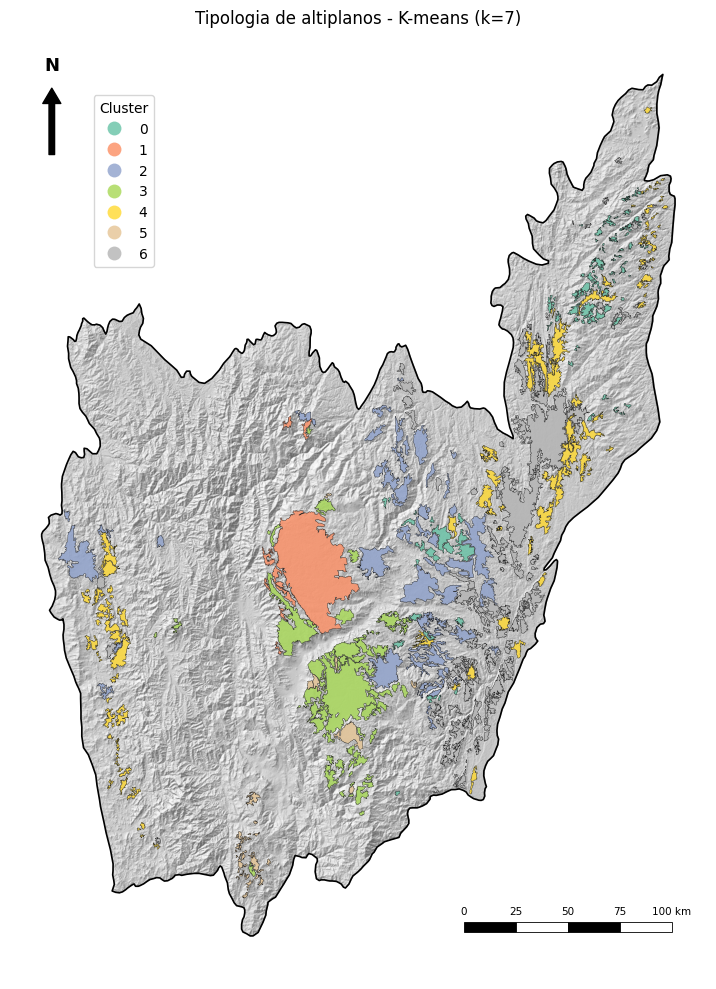

In [17]:
# Importa la plantilla cartográfica común del proyecto (hillshade + norte + escala + área de estudio).
from plantilla_mapas import aplicar_plantilla_mapa, posicionar_leyenda, CARPETA_IMAGENES

CARPETA_IMAGENES_NB = os.path.join(CARPETA_IMAGENES, "01_clustering_altiplanos_v2")  # subcarpeta en Imágenes/
os.makedirs(CARPETA_IMAGENES_NB, exist_ok=True)

fig, ax = plt.subplots(1, figsize=(10, 10))
# aplicar_plantilla_mapa dibuja hillshade+área+norte+escala y devuelve el "ancla" para ubicar la leyenda.
ancla = aplicar_plantilla_mapa(ax)
# Se vuelve a graficar el MISMO mapa de clusters, ahora encima de la plantilla:
# alpha=0.8 (20% transparente para dejar ver el hillshade), zorder=5 (dibuja por encima del fondo).
gdf.plot(column="cluster_kmeans", categorical=True, legend=True, cmap="Set2", alpha=0.8,
         edgecolor="black", linewidth=0.3, ax=ax, zorder=5,
         legend_kwds=posicionar_leyenda(ax, ancla, titulo="Cluster"))  # coloca la leyenda junto al norte
ax.set_title(f"Tipologia de altiplanos - K-means (k={K_ELEGIDO})")
ax.set_axis_off()
plt.tight_layout()
plt.savefig(os.path.join(CARPETA_IMAGENES_NB, "04_mapa_clusters.png"), dpi=150)  # versión cartográfica en Imágenes/
plt.show()

## [10] Perfilamiento de los clusters (interpretación)

Los clusters solo son números (0, 1, 2...) hasta que se les da un nombre geomorfológico.
Este paso calcula el perfil promedio de cada grupo y su distribución de litología
dominante.


In [18]:
# groupby("cluster_kmeans")[...].mean(): promedia cada variable dentro de cada cluster
# -> "perfil" morfométrico medio de cada tipo de altiplano (una fila por cluster).
perfil_clusters = gdf.groupby("cluster_kmeans")[variables_cluster].mean()
print("Perfil promedio por cluster (K-means):")
print(perfil_clusters)

Perfil promedio por cluster (K-means):
                  Altitud_X  Altitud_St       Alt_90       Alt_50  \
cluster_kmeans                                                      
0               1339.181389   28.550299  1376.842105  1338.957895   
1               2771.177778   77.021256  2870.444444  2770.111111   
2               1224.017714   53.134916  1295.482143  1221.321429   
3               2390.785098   47.237014  2452.823529  2389.490196   
4                675.673059   28.403285   712.457627   674.991525   
5               2504.984773   32.096395  2548.204545  2504.181818   
6                723.542517   31.522345   765.169492   722.957627   

                     Alt_10  Relieve_X  Relieve_St     Pend_X   Pend_St  
cluster_kmeans                                                           
0               1301.705263  45.430463   10.842391  12.167131  5.837154  
1               2667.333333  60.180978   22.179044  14.829778  7.635669  
2               1156.446429  51.809796   16

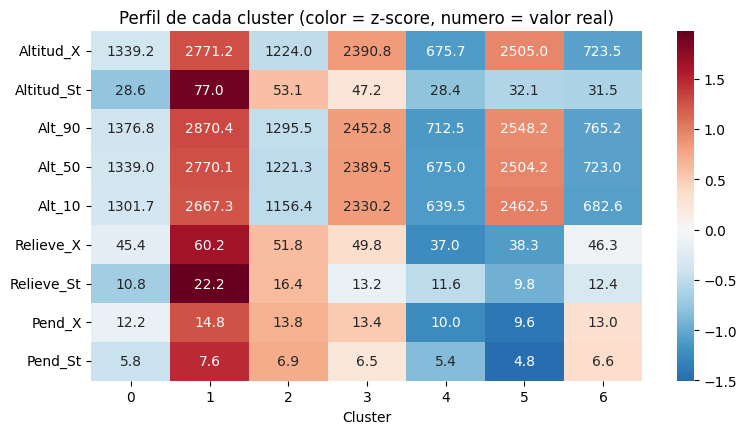

In [19]:
# Normaliza el perfil por columna (z-score entre clusters) para que el color sea comparable
# entre variables con escalas distintas: (valor - media) / desv. estándar de cada variable.
perfil_normalizado = (perfil_clusters - perfil_clusters.mean()) / perfil_clusters.std()

# El alto de la figura crece un poco si hay más de 4 clusters (para que quepan las filas).
plt.figure(figsize=(8, 4 + 0.15 * max(0, K_ELEGIDO - 4)))
# heatmap: color = z-score (perfil_normalizado.T); annot = número real (perfil_clusters.T); center=0 -> blanco en la media.
sns.heatmap(perfil_normalizado.T, annot=perfil_clusters.T, fmt=".1f", cmap="RdBu_r", center=0)
plt.title("Perfil de cada cluster (color = z-score, numero = valor real)")
plt.xlabel("Cluster")
plt.tight_layout()
plt.savefig(os.path.join(CARPETA_FIGURAS, "05_heatmap_perfil_clusters.png"), dpi=150)
plt.show()

In [20]:
# crosstab con normalize="index": % de cada litología DENTRO de cada cluster (cada fila suma 100).
# *100 lo pasa de proporción a porcentaje.
composicion_geologia = pd.crosstab(gdf["cluster_kmeans"], gdf["Geología"], normalize="index") * 100
print("Composicion litologica por cluster (% de poligonos):")
print(composicion_geologia.round(1))  # redondea a 1 decimal

Composicion litologica por cluster (% de poligonos):
Geología        I. Plutónica  I. Volcánica  M. Alto grado  M. Medio grado  \
cluster_kmeans                                                              
0                       47.4           2.1            0.0             7.4   
1                       11.1           0.0            0.0            66.7   
2                       53.6           1.8            8.9            16.1   
3                       49.0           2.0            3.9            35.3   
4                       59.3          12.7            0.0             1.7   
5                        6.8          77.3            0.0            11.4   
6                       33.9           1.7            4.2            20.3   

Geología        S. Fino  S. Gruesos  S. Medio  
cluster_kmeans                                 
0                   0.0         0.0      43.2  
1                   0.0         0.0      22.2  
2                   1.8         0.0      17.9  
3            

## [11] Exportar resultados

Se guarda el GeoDataFrame con las columnas de cluster añadidas. Se usa el sufijo `_v2` para
no sobrescribir `Resultados\altiplanos_clasificados.gpkg` (capa de la version anterior).


In [21]:
ruta_salida = os.path.join(CARPETA_RESULTADOS, "altiplanos_clasificados_v2.gpkg")
# to_file con driver="GPKG": guarda el GeoDataFrame (geometría + columnas de cluster) como GeoPackage.
# Se usa .gpkg y NO .shp para evitar el bug de codificación del .dbf (nombres de columna con acentos).
gdf.to_file(ruta_salida, driver="GPKG")
print(f"Resultado guardado en: {ruta_salida}")

Resultado guardado en: C:\Users\MSI\Desktop\Universidad\Analisis_Geoespacial\Resultados\altiplanos_clasificados_v2.gpkg


## Conclusiones y siguientes pasos

- El criterio de Silhouette restringido a `n_clusters >= 4` eligió `K_ELEGIDO` de forma
  reproducible en vez de un valor fijado a mano, dejando trazado en el propio notebook el
  porqué de esa decisión.
- K-means y Ward coinciden razonablemente en la tipología resultante (ver tabla de
  contingencia de la sección [8]), lo que da confianza en que la tipología encontrada no es
  un artefacto de un solo algoritmo.
- **Nota sobre TimeSeriesKMeans/DTW:** una versión anterior de este notebook exploraba un
  clustering alternativo con distancia DTW (Dynamic Time Warping), tratando las 9 variables
  estandarizadas como una "secuencia". Se retiró de esta versión: DTW solo aporta valor
  cuando existe un eje temporal/secuencial real que se pueda "estirar o comprimir" al
  comparar dos observaciones, y las 9 variables morfométricas de este análisis no tienen
  ningún orden natural entre sí (el orden en que aparecen en la tabla es arbitrario), así
  que el mecanismo central de DTW no corresponde a nada físicamente significativo aquí. En
  las pruebas ya realizadas, además, K-means euclidiano superó a DTW en Silhouette para
  todos los valores de k comparados, confirmando que la distancia euclidiana simple es
  suficiente y más apropiada para este conjunto de datos.
- **Siguientes pasos sugeridos (fuera del alcance de este notebook):**
  1. Explorar si existe autocorrelación espacial en la UBICACIÓN de cada tipo — ver
     `04_autocorrelacion_espacial_v2.ipynb`.
  2. Comparar esta tipología basada solo en atributos contra la versión con restricción
     espacial (KNN/DistanceBand) de `02_clustering_espacial_altiplanos_v2.ipynb`.
